# 02 — Data pipeline audit

This notebook performs a read-only audit of the data already stored in `data/`. It does not rerun
`fetch_series.py` or `build_tidy_tables.py`, and it does not modify any source files.

The checks below inspect the actual data values and structure. Automated pass/fail checks are handled separately by `tests/test_data_coverage.py`.

## 1. Setup
Imports, project paths, and display options used throughout the audit.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")


REPO_ROOT = find_repo_root(Path.cwd())
RAW_DIR = REPO_ROOT / "data" / "raw"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"

## 2. Inspect the raw data
This section checks the files currently stored in `data/raw/`: their number, total size, and the
structure of a representative raw FRED response. The raw file is inspected before any parsing or
transformation is applied.

Expected: 29 raw files, one for each series in the manifest, with the standard FRED fields
`realtime_start`, `realtime_end`, `date`, and `value`. The raw value field is retained as text at
this stage, including  `"."` for missing observations.

In [2]:
raw_files = sorted(RAW_DIR.glob("*.csv"))
total_size_mb = sum(f.stat().st_size for f in raw_files) / (1024 * 1024)
print(f"{len(raw_files)} files in data/raw/, {total_size_mb:.2f} MB total")

29 files in data/raw/, 1.96 MB total


In [3]:
sample_raw = pd.read_csv(RAW_DIR / "WCOILWTICO.csv")
sample_raw.head()

,realtime_start,realtime_end,date,value
0,2026-08-05,2026-08-05,2010-01-01,79.07
1,2026-08-05,2026-08-05,2010-01-08,82.34
2,2026-08-05,2026-08-05,2010-01-15,80.06
3,2026-08-05,2026-08-05,2010-01-22,76.62
4,2026-08-05,2026-08-05,2010-01-29,73.94


## 3. Fetch summary
One row per series, showing row count, date range, and how many observations carried FRED's
`"."` missing-value marker. Each row is joined to `kind`/`freq`/`role` from
`data/processed/series_manifest.csv`.

Checks: the number of series should match the manifest, missing-value counts should be consistent with the expected coverage of each series, and the observed date ranges should be plausible for the corresponding series.

In [4]:
manifest_df = pd.read_csv(PROCESSED_DIR / "series_manifest.csv")

summary_rows = []
for path in sorted(RAW_DIR.glob("*.csv")):
    series_id = path.stem
    raw = pd.read_csv(path, dtype=str)
    summary_rows.append(
        {
            "series_id": series_id,
            "rows": len(raw),
            "first_date": raw["date"].min(),
            "last_date": raw["date"].max(),
            "nan_count": (raw["value"] == ".").sum(),
        }
    )

fetch_summary = pd.DataFrame(summary_rows).merge(
    manifest_df[["series_id", "kind", "freq", "role"]], on="series_id", how="left"
)
fetch_summary = fetch_summary.sort_values(["kind", "freq"]).reset_index(drop=True)
fetch_summary

,series_id,rows,first_date,last_date,nan_count,kind,freq,role
0,DCOILBRENTEU,4327,2010-01-01,2026-08-03,131,crude,daily,robustness
1,DCOILWTICO,4327,2010-01-01,2026-08-03,168,crude,daily,core
2,WCOILBRENTEU,866,2010-01-01,2026-07-31,0,crude,weekly-fri,robustness
3,WCOILWTICO,866,2010-01-01,2026-07-31,0,crude,weekly-fri,core
4,GASDESECW,866,2010-01-04,2026-08-03,0,retail,weekly-mon,comparison
5,GASDESGCW,866,2010-01-04,2026-08-03,0,retail,weekly-mon,comparison
6,GASDESMWW,866,2010-01-04,2026-08-03,0,retail,weekly-mon,comparison
7,GASDESRMW,866,2010-01-04,2026-08-03,0,retail,weekly-mon,comparison
8,GASDESW,866,2010-01-04,2026-08-03,0,retail,weekly-mon,comparison
9,GASDESWCW,866,2010-01-04,2026-08-03,0,retail,weekly-mon,comparison


## 4. Inspect the tidy tables
The parsed `crude.csv`, `spot.csv`, and `retail.csv` tables are checked for their dimensions,
frequency composition, and a sample of observations. Row counts should be broadly consistent
with the fetch summary above.

In [5]:
crude = pd.read_csv(PROCESSED_DIR / "crude.csv", parse_dates=["date"])
spot = pd.read_csv(PROCESSED_DIR / "spot.csv", parse_dates=["date"])
retail = pd.read_csv(PROCESSED_DIR / "retail.csv", parse_dates=["date"])

tables = {"crude": crude, "spot": spot, "retail": retail}

for name, df in tables.items():
    print(f"--- {name}: shape ---")
    print(df.shape)
    print(df["freq"].value_counts())
    print()

--- crude: shape ---
(10386, 6)
freq
daily         8654
weekly-fri    1732
Name: count, dtype: int64

--- spot: shape ---
(31162, 7)
freq
daily         25966
weekly-fri     5196
Name: count, dtype: int64

--- retail: shape ---
(11258, 7)
freq
weekly-mon    11258
Name: count, dtype: int64



In [6]:
for name, df in tables.items():
    print(f"--- {name}: head(3) ---")
    display(df.head(3))

--- crude: head(3) ---


,date,series_id,benchmark,freq,price_usd_per_barrel,price_usd_per_gallon
0,2010-01-01,DCOILBRENTEU,Brent,daily,NaN,NaN
1,2010-01-04,DCOILBRENTEU,Brent,daily,79.05,1.882143
2,2010-01-05,DCOILBRENTEU,Brent,daily,79.27,1.887381


--- spot: head(3) ---


,date,series_id,hub,fuel,formulation,freq,price_usd_per_gallon
0,2010-01-01,DDFUELLA,Los Angeles,diesel,NaN,daily,NaN
1,2010-01-04,DDFUELLA,Los Angeles,diesel,NaN,daily,2.209
2,2010-01-05,DDFUELLA,Los Angeles,diesel,NaN,daily,2.190


--- retail: head(3) ---


,date,series_id,region,fuel,formulation,freq,price_usd_per_gallon
0,2010-01-04,GASDESECW,PADD 1,diesel,NaN,weekly-mon,2.827
1,2010-01-11,GASDESECW,PADD 1,diesel,NaN,weekly-mon,2.922
2,2010-01-18,GASDESECW,PADD 1,diesel,NaN,weekly-mon,2.923


## 5. Coverage
Four checks, each showing the actual rows rather than a pass/fail:
- day-of-week counts per `freq`, for each table
- every retail observation where the gap to the previous one (same series) isn't 7 days
- every row with a negative price, in any table
- every weekend row in a daily series, and whether its price is null

Checks: weekly series should fall on their expected weekday; retail observations should normally be seven days apart; negative prices should correspond to known events; and weekend observations in daily series should be absent or explicitly null.

In [7]:
for name, df in tables.items():
    print(f"=== {name}: day-of-week counts by freq ===")
    for freq, group in df.groupby("freq"):
        print(f"-- {freq} --")
        print(group["date"].dt.day_name().value_counts())
    print()

=== crude: day-of-week counts by freq ===
-- daily --
date
Friday       1732
Monday       1732
Tuesday      1730
Wednesday    1730
Thursday     1730
Name: count, dtype: int64
-- weekly-fri --
date
Friday    1732
Name: count, dtype: int64

=== spot: day-of-week counts by freq ===
-- daily --
date
Friday       5196
Monday       5196
Tuesday      5190
Wednesday    5190
Thursday     5190
Saturday        4
Name: count, dtype: int64
-- weekly-fri --
date
Friday    5196
Name: count, dtype: int64

=== retail: day-of-week counts by freq ===
-- weekly-mon --
date
Monday    11258
Name: count, dtype: int64



In [8]:
retail_sorted = retail.sort_values(["series_id", "date"]).copy()
retail_sorted["gap_days"] = retail_sorted.groupby("series_id")["date"].diff().dt.days

irregular_gaps = retail_sorted[retail_sorted["gap_days"].notna() & (retail_sorted["gap_days"] != 7)]
print("irregular gaps retail rows:")
irregular_gaps[["series_id", "date", "gap_days"]]

irregular gaps retail rows:


,series_id,date,gap_days


In [9]:
negative_crude = crude[(crude["price_usd_per_barrel"] < 0) | (crude["price_usd_per_gallon"] < 0)]
negative_spot = spot[spot["price_usd_per_gallon"] < 0]
negative_retail = retail[retail["price_usd_per_gallon"] < 0]

print("negative crude rows:")
display(negative_crude)
print("negative spot rows:")
display(negative_spot)
print("negative retail rows:")
display(negative_retail)

negative crude rows:


,date,series_id,benchmark,freq,price_usd_per_barrel,price_usd_per_gallon
7013,2020-04-20,DCOILWTICO,WTI,daily,-36.98,-0.880476


negative spot rows:


,date,series_id,hub,fuel,formulation,freq,price_usd_per_gallon


negative retail rows:


,date,series_id,region,fuel,formulation,freq,price_usd_per_gallon


In [10]:
price_col_by_table = {"crude": "price_usd_per_barrel", "spot": "price_usd_per_gallon", "retail": "price_usd_per_gallon"}

weekend_daily_frames = []
for name, df in tables.items():
    daily = df[df["freq"] == "daily"].copy()
    if daily.empty:
        continue
    weekend = daily[daily["date"].dt.dayofweek >= 5].copy()
    weekend["table"] = name
    weekend["price_is_null"] = weekend[price_col_by_table[name]].isna()
    weekend_daily_frames.append(weekend[["table", "series_id", "date", "price_is_null"]])

weekend_daily = (
    pd.concat(weekend_daily_frames, ignore_index=True)
    if weekend_daily_frames
    else pd.DataFrame(columns=["table", "series_id", "date", "price_is_null"])
)
weekend_daily

,table,series_id,date,price_is_null
0,spot,DDFUELNYH,2010-11-13,True
1,spot,DDFUELNYH,2010-11-20,True
2,spot,DDFUELUSGULF,2010-11-13,True
3,spot,DDFUELUSGULF,2010-11-20,True


## 6. Inspect the core price series
WTI crude and US retail regular gasoline are plotted over the full sample as a visual check of
their coverage, overall behavior, and relative timing. The series remain in their native units \$/barrel and \$/gallon.

Checks: both series should have continuous coverage consistent with the earlier audit, and their major movements should broadly correspond without unexplained gaps.

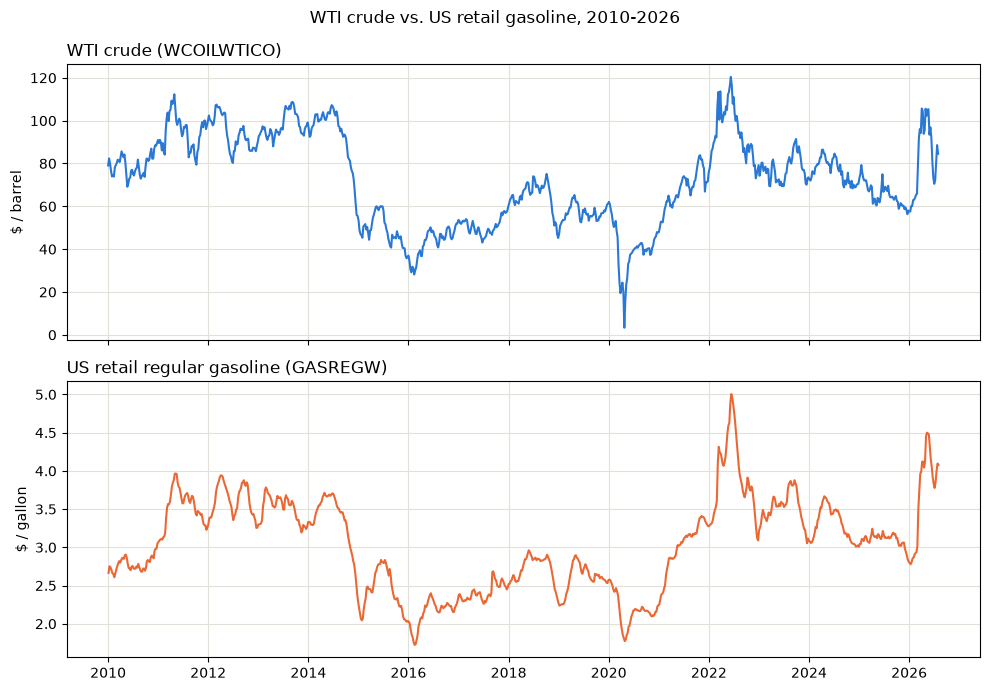

In [11]:
wti = crude[(crude["series_id"] == "WCOILWTICO") & (crude["date"] >= "2010-01-01")]
retail_us = retail[(retail["series_id"] == "GASREGW") & (retail["date"] >= "2010-01-01")]

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax_top.plot(wti["date"], wti["price_usd_per_barrel"], color="#2a78d6", linewidth=1.5)
ax_top.set_ylabel("$ / barrel")
ax_top.set_title("WTI crude (WCOILWTICO)", loc="left")
fig.suptitle("WTI crude vs. US retail gasoline, 2010-2026", fontsize=12)
ax_top.grid(True, color="#e1e0d9")

ax_bottom.plot(retail_us["date"], retail_us["price_usd_per_gallon"], color="#eb6834", linewidth=1.5)
ax_bottom.set_ylabel("$ / gallon")
ax_bottom.set_title("US retail regular gasoline (GASREGW)", loc="left")
ax_bottom.grid(True, color="#e1e0d9")

plt.tight_layout()
plt.show()

## 7. Observations

- **`DCOILWTICO` reached -\$36.98/barrel on 2020-04-20.** This is the well-known episode in which
WTI prices at Cushing turned negative during the COVID-19 demand collapse and severe storage
constraints. The observation is therefore treated as a real market event, not a data error.
- **Four weekend rows, all NaN**, appear in `DDFUELNYH` and `DDFUELUSGULF`, both on Saturdays
(2010-11-13 and 2010-11-20). These are consistent with markets being closed and no price being
reported.
- **The remaining checks are clean:** there are no irregular retail gaps across the 13 retail
series, no negative spot or retail prices, and all `weekly-fri` and `weekly-mon` observations
fall on their expected weekdays.